<a href="https://colab.research.google.com/github/Krishs15/CAPTCHA-Verification/blob/main/DL_LAB03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Download latest version
path = kagglehub.dataset_download("shubh0799/churn-modelling")

print("Path to dataset files:", path)

# Assuming the CSV file is named 'Churn_Modelling.csv' inside the downloaded directory
csv_file_path = os.path.join(path, 'Churn_Modelling.csv')

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first 10 rows of the DataFrame
display(df.head(10))

Using Colab cache for faster access to the 'churn-modelling' dataset.
Path to dataset files: /kaggle/input/churn-modelling


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [5]:
# 2. Feature Engineering
# Dropping unnecessary columns (RowNumber, CustomerId, Surname)
X = df.iloc[:, 3:-1].values
y = df.iloc[:, -1].values

# Encoding categorical data (Gender and Geography)
le = LabelEncoder()
X[:, 2] = le.fit_transform(X[:, 2]) # Gender

# For Geography (OneHotEncoding is better, but LabelEncoding is faster for experiments)
X[:, 1] = le.fit_transform(X[:, 1])

# Splitting and Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [6]:
# 3. Create ANN model with 5 dense layers
model = Sequential()
model.add(Dense(units=10, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(units=15, activation='relu'))
model.add(Dense(units=19, activation='relu'))
model.add(Dense(units=24, activation='relu'))
model.add(Dense(units=28, activation='relu'))
model.add(Dense(units=1, activation='sigmoid')) # Output Layer

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# 4. Train the model for 100 epochs
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=32)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6995 - loss: 0.5824 - val_accuracy: 0.8215 - val_loss: 0.4206
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8144 - loss: 0.4281 - val_accuracy: 0.8375 - val_loss: 0.3888
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8341 - loss: 0.3865 - val_accuracy: 0.8490 - val_loss: 0.3684
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8475 - loss: 0.3660 - val_accuracy: 0.8485 - val_loss: 0.3645
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8501 - loss: 0.3622 - val_accuracy: 0.8475 - val_loss: 0.3572
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8537 - loss: 0.3542 - val_accuracy: 0.8465 - val_loss: 0.3636
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8553 - loss: 0.3576 - val_accuracy: 0.8540 - val_loss: 0.3561
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8536 - loss: 0.3544 - val_accu

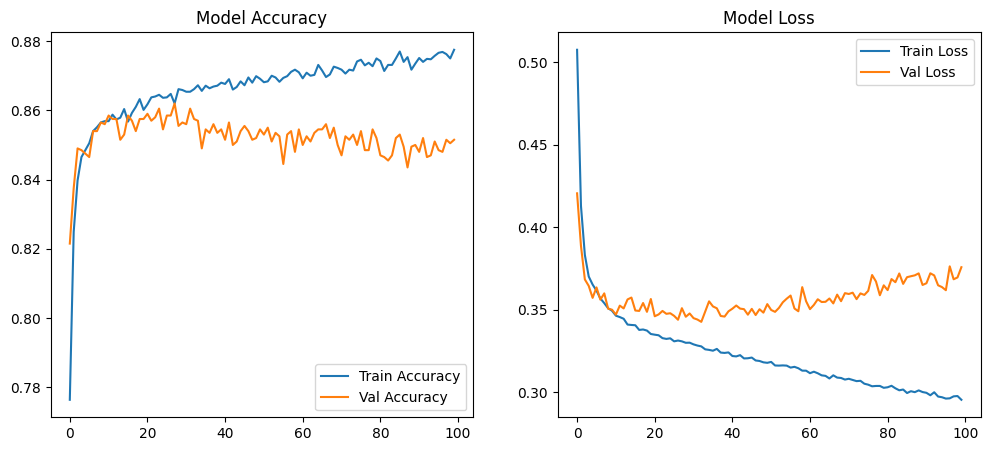

In [8]:
# 5. Draw the loss and Accuracy graph
plt.figure(figsize=(12, 5))

# Accuracy Graph
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Loss Graph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.show()